# Criando dataset para calcular as sessões por votações participadas:


In [79]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px

df_deputados = pd.read_json('../../data/processed/deputados.json') 
df_eventos = pd.read_csv('../../data/processed/eventos.csv')
df_presencas = pd.read_csv('../../data/processed/presencas.csv')
votacoes_all = pd.read_csv("../../data/processed/votacoes_2020-02_2025-10_todas.csv")

## 2. Sessões por Votações Participada

In [80]:
# Filtra só Sessão Deliberativa em df_eventos
df_sessoes = (
    df_eventos
    .loc[df_eventos["descricaoTipo"].eq("Sessão Deliberativa"),
         ["id", "dataHoraInicio", "descricaoTipo"]]
    .rename(columns={"id": "id_evento"})
)
total_sessoes = df_sessoes["id_evento"].nunique()
total_sessoes

392

In [81]:
# Total de votações possíveis
df_votacoes = votacoes_all[["id", "uriEvento"]].drop_duplicates()
votacoes_possiveis_totais = df_votacoes["id"].nunique()
votacoes_possiveis_totais


6027

In [82]:
# Mapeando cada votação para o evento (sessão) em que ela ocorreu 
# via uriEvento → uri → id_evento

# todas as votações pegando o id a uri do evento e renomeando id para id votação
df_vot_evento = (
    votacoes_all[["id", "uriEvento"]]
    .drop_duplicates()
    .rename(columns={"id": "id_votacao"})
)

df_vot_evento = df_vot_evento.merge(
    df_eventos[["id", "uri"]],
    left_on="uriEvento",
    right_on="uri",
    how="left"
)

# renomeia id do evento e limpa a coluna uri redundante
df_vot_evento = (
    df_vot_evento
    .rename(columns={"id": "id_evento"})
    .drop(columns=["uri"])
)

df_vot_evento

,id_votacao,uriEvento,id_evento
0,2229565-3,https://dadosabertos.camara.leg.br/api/v2/even...,59253.0
1,2236289-5,https://dadosabertos.camara.leg.br/api/v2/even...,59265.0
2,2236343-34,https://dadosabertos.camara.leg.br/api/v2/even...,59265.0
3,2236481-5,https://dadosabertos.camara.leg.br/api/v2/even...,59265.0
4,2236329-2,https://dadosabertos.camara.leg.br/api/v2/even...,59253.0
...,...,...,...
6022,2485222-26,NaN,NaN
6023,2474309-24,NaN,NaN
6024,2195860-74,NaN,NaN
6025,2121416-88,NaN,NaN


In [83]:
# ligar presença (deputado) com votação

# garantir mesmo tipo em id_evento
df_presencas["id_evento"]  = pd.to_numeric(df_presencas["id_evento"], errors="coerce")
df_vot_evento["id_evento"] = pd.to_numeric(df_vot_evento["id_evento"], errors="coerce")

# tira eventuais NaN em id_evento
df_presencas  = df_presencas.dropna(subset=["id_evento"])
df_vot_evento = df_vot_evento.dropna(subset=["id_evento"])

# agora cada linha será: deputado presente em um evento + votações daquele evento
df_pres_vot = (
    df_presencas[["id_evento", "id_deputado"]]
    .merge(
        df_vot_evento[["id_evento", "id_votacao"]],
        on="id_evento",
        how="inner"
    )
)

df_pres_vot = df_pres_vot.drop_duplicates(["id_deputado", "id_votacao"])
df_pres_vot 

,id_evento,id_deputado,id_votacao
0,59216,74299,2232405-2
1,59216,74299,2232493-2
2,59216,74299,2232492-2
3,59216,143084,2232405-2
4,59216,143084,2232493-2
...,...,...,...
986894,79500,220685,2565415-2
986895,79500,220685,2565223-2
986896,79500,220685,2565224-2
986897,79500,220685,2554712-48


In [84]:
# contagem de votações participadas por deputado

df_vot_por_dep = (
    df_pres_vot
    .groupby("id_deputado", as_index=False)["id_votacao"]
    .nunique()
    .rename(columns={"id_votacao": "votacoes_participadas"})
)

df_vot_por_dep

,id_deputado,votacoes_participadas
0,62881,1827
1,66179,1248
2,66385,519
3,66828,2028
4,67138,1093
...,...,...
890,230957,149
891,231911,52
892,233592,14
893,233594,7


In [86]:
# garantir tipos numéricos compatíveis
df_sessoes["id_evento"] = pd.to_numeric(df_sessoes["id_evento"], errors="coerce")
df_presencas["id_evento"] = pd.to_numeric(df_presencas["id_evento"], errors="coerce")

# presenças só em Sessão Deliberativa + remove duplicatas (evento, deputado)
df_pres_clean = (
    df_presencas[["id_evento", "id_deputado"]]
    .dropna()
)

df_pres_clean = df_pres_clean[
    df_pres_clean["id_evento"].isin(df_sessoes["id_evento"])
].drop_duplicates()

df_pres_clean

,id_evento,id_deputado
249,59265,66179
250,59265,66828
251,59265,67138
252,59265,68720
253,59265,69871
...,...,...
557755,79645,231911
557756,79645,233218
557757,79645,233592
557758,79645,233594


In [88]:
df_pres_por_dep = (
    df_pres_clean
    .groupby("id_deputado", as_index=False)["id_evento"]
    .nunique()
    .rename(columns={"id_evento": "presencas"})
)

df_pres_por_dep

,id_deputado,presencas
0,62881,266
1,66179,221
2,66385,120
3,66828,329
4,67138,197
...,...,...
893,231911,27
894,233218,9
895,233592,8
896,233594,8


In [90]:
df_dep_nomes = (
    df_deputados
    .rename(columns={"id": "id_deputado", "nome": "deputado"})
    [["id_deputado", "deputado"]]
)

df_dep_nomes

,id_deputado,deputado
0,204379,Acácio Favacho
1,220714,Adail Filho
2,221328,Adilson Barroso
3,204560,Adolfo Viana
4,204528,Adriana Ventura
...,...,...
508,220558,Zé Trovão
509,204517,Zé Vitor
510,160592,Zeca Dirceu
511,220592,Zezinho Barbary


In [92]:
# df_vot_por_dep: id_deputado, votacoes_participadas

df_dep_votacao = (
    df_vot_por_dep
    .merge(df_pres_por_dep, on="id_deputado", how="left")
    .merge(df_dep_nomes,   on="id_deputado", how="left")
)

df_dep_votacao

,id_deputado,votacoes_participadas,presencas,deputado
0,62881,1827,266,Danilo Forte
1,66179,1248,221,NaN
2,66385,519,120,Julio Arcoverde
3,66828,2028,329,Fausto Pinato
4,67138,1093,197,NaN
...,...,...,...,...
890,230957,149,38,João Cury
891,231911,52,27,Lenir de Assis
892,233592,14,8,Paulo Lemos
893,233594,7,8,Rafael Fera


In [94]:
# se quiser garantir aqui, pode recalcular:
# total_sessoes = df_sessoes["id_evento"].nunique()
# votacoes_possiveis_totais = df_votacoes["id"].nunique()

df_dep_votacao["sessoes_total"] = total_sessoes
df_dep_votacao["taxa_votacao"] = (
    df_dep_votacao["votacoes_participadas"] / votacoes_possiveis_totais
)

# organiza as colunas
df_dep_votacao = df_dep_votacao[
    ["id_deputado",
     "deputado",
     "presencas",
     "sessoes_total",
     "votacoes_participadas",
     "taxa_votacao"]
]

df_dep_votacao

,id_deputado,deputado,presencas,sessoes_total,votacoes_participadas,taxa_votacao
0,62881,Danilo Forte,266,392,1827,0.303136
1,66179,NaN,221,392,1248,0.207068
2,66385,Julio Arcoverde,120,392,519,0.086112
3,66828,Fausto Pinato,329,392,2028,0.336486
4,67138,NaN,197,392,1093,0.181351
...,...,...,...,...,...,...
890,230957,João Cury,38,392,149,0.024722
891,231911,Lenir de Assis,27,392,52,0.008628
892,233592,Paulo Lemos,8,392,14,0.002323
893,233594,Rafael Fera,8,392,7,0.001161


In [96]:
# Checando se existe alguma presença NaN
df_dep_votacao.presencas.isna().value_counts() 

presencas
False    895
Name: count, dtype: int64

<Axes: >

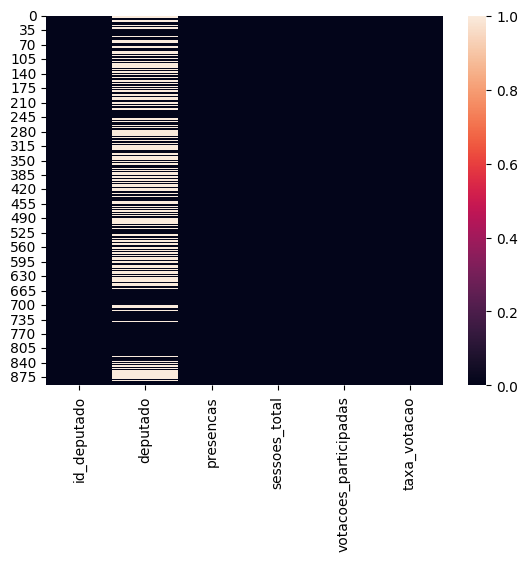

In [97]:
sns.heatmap(df_dep_votacao.isna()) # ver valores faltantes
# Alguns nomes de deputados estão em branco, solução é filtrar pelo seu ID no streamlit

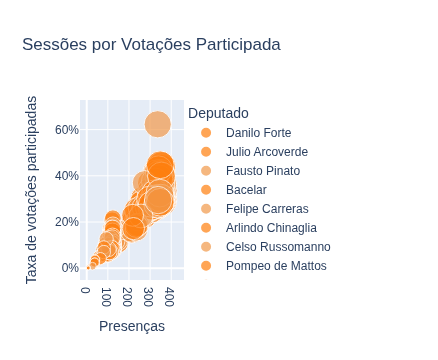

In [103]:
palette_light_orange = "#f2994a"
fig2 = px.scatter(
    df_dep_votacao,
    x="presencas",
    y="taxa_votacao",
    size="presencas",
    hover_name="deputado",
    color="deputado",
    color_discrete_sequence=[palette_main, palette_light_orange],
    labels={
        "sessoes_total": "Número de sessões",
        "taxa_votacao": "Taxa de votações participadas",
        "presencas": "Presenças",
        "deputado": "Deputado",
    },
    title="Sessões por Votações Participada",
)

fig2.update_layout(yaxis_tickformat=".0%")


In [102]:
df_dep_votacao.to_csv("../../data/graphs/df_dep_votacao.csv", index=False)
